# **Dataset Creation**

This notebook demonstrates the complete data preparation workflow for the satellite image matching project.

The notebook includes:

- loading Sentinel-2 Level-1C scenes;
- locating the `IMG_DATA` directory;
- reading the RGB spectral bands;
- constructing natural-color RGB images;
- splitting images into 1024×1024 tiles;
- preparing the final dataset for the LoFTR matching pipeline.

## Dataset

For this project I used Sentinel-2 Level-1C satellite imagery from the public Kaggle dataset:
https://www.kaggle.com/datasets/isaienkov/deforestation-in-ukraine

I chose the Kaggle dataset because it already contains the required Sentinel-2 scenes in the standard `.SAFE` format.

Sentinel-2 provides multispectral images with 13 spectral bands. For this project, two scenes of the same geographic area acquired on different dates were selected for image matching.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from src.io import (find_img_data,read_rgb_bands,)
from src.tiling import process_image

## Input scenes

In [ ]:
safe_dir1 = Path("../data/S2A_MSIL1C_20160621T084012_N0204_R064_T36UYA_20160621T084513.SAFE")
safe_dir2 = Path("../data/S2A_MSIL1C_20160212T084052_N0201_R064_T36UYA_20160212T084510.SAFE")

S2A_MSIL1C_20160621T084012_N0204_R064_T36UYA_20160621T084513.SAFE
S2A_MSIL1C_20160212T084052_N0201_R064_T36UYA_20160212T084510.SAFE


In [5]:
img_dir1 = find_img_data(safe_dir1)
img_dir2 = find_img_data(safe_dir2)
print(img_dir1)
print(img_dir2)

..\data\S2A_MSIL1C_20160621T084012_N0204_R064_T36UYA_20160621T084513.SAFE\GRANULE\L1C_T36UYA_A005209_20160621T084513\IMG_DATA
..\data\S2A_MSIL1C_20160212T084052_N0201_R064_T36UYA_20160212T084510.SAFE\GRANULE\L1C_T36UYA_A003350_20160212T084510\IMG_DATA


## Sentinel-2 directory structure

Each Sentinel-2 scene is stored in the `.SAFE` format.
The RGB bands are located inside the `IMG_DATA` directory.

In [32]:
img_dir = find_img_data(safe_dir1)

for file in sorted(img_dir.glob("*.jp2")):
    print(file.name)

T36UYA_20160621T084012_B01.jp2
T36UYA_20160621T084012_B02.jp2
T36UYA_20160621T084012_B03.jp2
T36UYA_20160621T084012_B04.jp2
T36UYA_20160621T084012_B05.jp2
T36UYA_20160621T084012_B06.jp2
T36UYA_20160621T084012_B07.jp2
T36UYA_20160621T084012_B08.jp2
T36UYA_20160621T084012_B09.jp2
T36UYA_20160621T084012_B10.jp2
T36UYA_20160621T084012_B11.jp2
T36UYA_20160621T084012_B12.jp2
T36UYA_20160621T084012_B8A.jp2
T36UYA_20160621T084012_TCI.jp2


## RGB bands

Sentinel-2 provides 13 spectral bands covering visible, near-infrared and shortwave infrared wavelengths.

For this project, only the visible RGB bands are used to construct a natural-color image:

- **B04** — Red
- **B03** — Green
- **B02** — Blue

These three bands are stacked together to create a standard RGB image that is later used for image matching

## RGB construction

In [9]:
rgb1 = read_rgb_bands(img_dir1)
rgb2 = read_rgb_bands(img_dir2)
print(rgb1.shape)
print(rgb1.dtype)
print(rgb1.min(), rgb1.max())


(10980, 10980, 3)
float32
0.0 1.0


## RGB images of the selected scenes

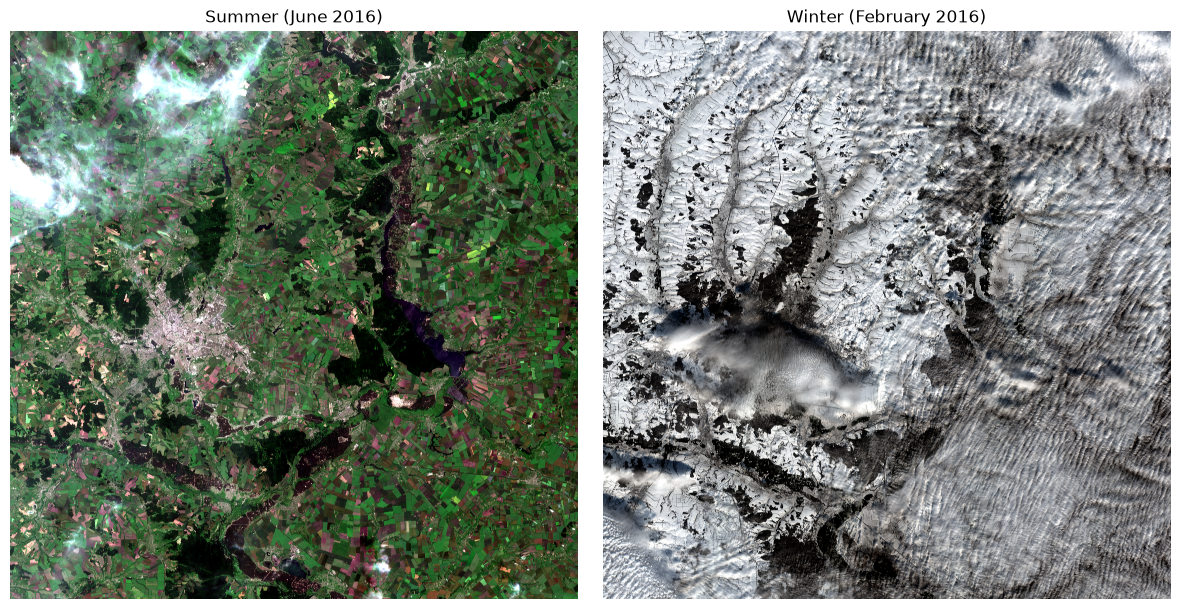

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(rgb1)
ax[0].set_title("Summer (June 2016)")

ax[1].imshow(rgb2)
ax[1].set_title("Winter (February 2016)")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

## Image tiling

The original Sentinel-2 image has a spatial resolution of **10980 × 10980 pixels**, which is too large to process efficiently as a whole.

Therefore, the image is divided into fixed-size tiles of:

- **1024 × 1024 pixels**

Each tile is processed independently. During the preprocessing stage, tiles containing large NoData regions are discarded, while only valid tiles are kept for further image matching.

## Tile extraction

In [12]:
image1, good_tiles1 = process_image(safe_dir1)
image2, good_tiles2 = process_image(safe_dir2)

Image size : (10980, 10980, 3)
Good tiles : 97
Image size : (10980, 10980, 3)
Good tiles : 95


## Valid tiles from the summer scene

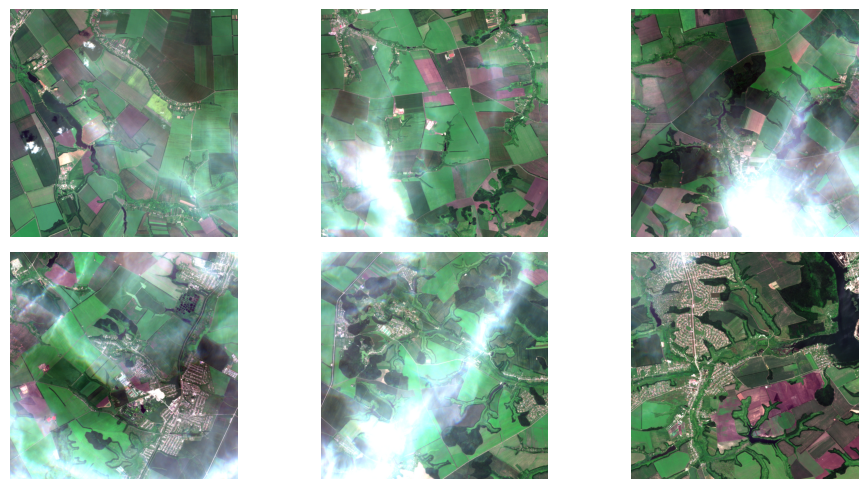

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(10, 5))

tiles = list(good_tiles1.values())

for i, axis in enumerate(ax.ravel()):
    axis.imshow(tiles[i])
    axis.axis("off")

plt.tight_layout()
plt.show()

## Examples of valid winter tiles

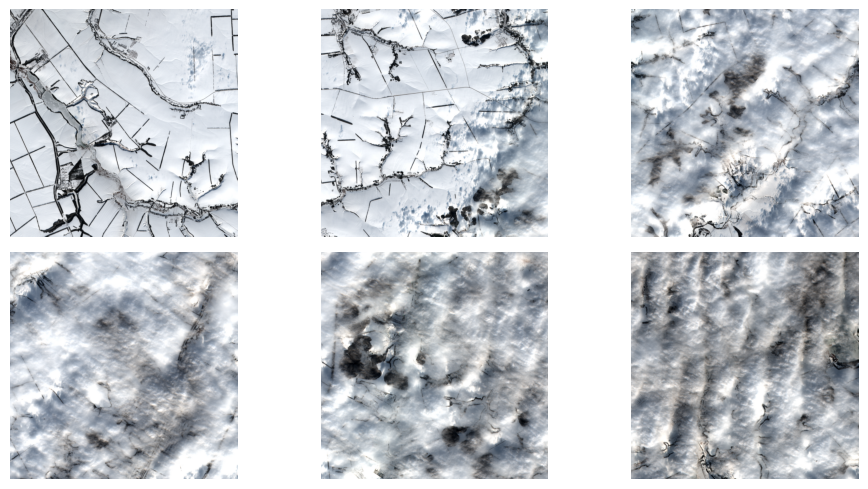

In [ ]:
fig, ax = plt.subplots(2,3,figsize=(10,5))

tiles = list(good_tiles2.values())
for i, a in enumerate(ax.ravel()):
    a.imshow(tiles[i])
    a.axis("off")

plt.tight_layout()
plt.show()

## Tile statistics

In [ ]:

tile_sizes1 = [tile.shape[:2] for tile in good_tiles1.values()]
tile_sizes2 = [tile.shape[:2] for tile in good_tiles2.values()]

stats = pd.DataFrame({
    "Property": [
        "Valid tiles",
        "Tile size"
    ],
    "Summer scene": [
        len(tile_sizes1),
        f"{tile_sizes1[0][0]} × {tile_sizes1[0][1]}"
    ],
    "Winter scene": [
        len(tile_sizes2),
        f"{tile_sizes2[0][0]} × {tile_sizes2[0][1]}"
    ]
})

stats

,Property,Summer scene,Winter scene
0,Valid tiles,97,95
1,Tile size,1024 × 1024,1024 × 1024


## Brightness Distribution of Valid Image Tiles

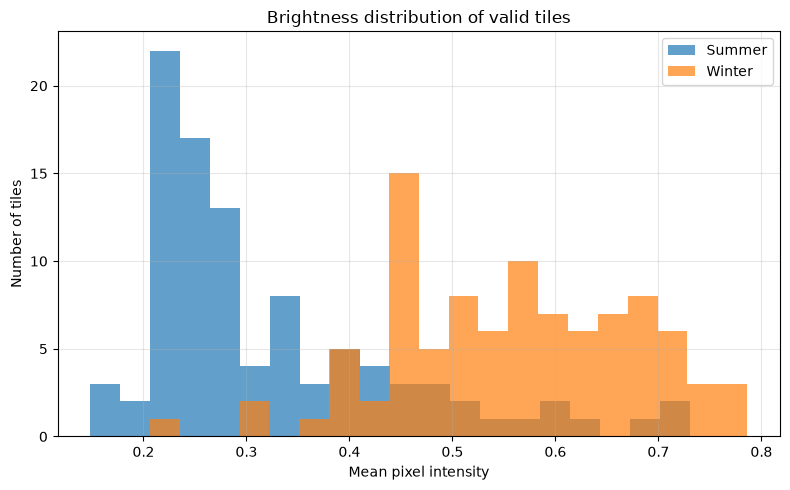

In [ ]:
means1 = [
    tile.mean()
    for tile in good_tiles1.values()
]

means2 = [
    tile.mean()
    for tile in good_tiles2.values()
]

plt.figure(figsize=(8, 5))

plt.hist(
    means1,
    bins=20,
    alpha=0.7,
    label="Summer",
)

plt.hist(
    means2,
    bins=20,
    alpha=0.7,
    label="Winter",
)

plt.xlabel("Mean pixel intensity")
plt.ylabel("Number of tiles")
plt.title("Brightness distribution of valid tiles")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

In this notebook, the Sentinel-2 dataset was prepared for the image matching pipeline.

The preparation process included:

- locating the Sentinel-2 `IMG_DATA` directory;
- reading the RGB spectral bands (B04, B03 and B02);
- constructing natural-color RGB images;
- splitting the images into fixed-size 1024×1024 tiles;
- filtering invalid tiles containing large NoData regions.

The resulting valid image tiles are used as input for the LoFTR-based image matching algorithm presented in the demo notebook.

The prepared dataset is now ready for feature matching and image registration.